In [1]:
import backend as ba

# Introduction

This notebook provides an **educational introduction to a basic Topological Data Analysis (TDA) workflow using financial time-series data**. The goal is not to develop a trading strategy or to claim that TDA provides a superior measure of market stress. Instead, the project demonstrates how persistence diagrams can be constructed, normalized, visualized, and compared with familiar statistical measures.

Daily returns of 24 German stocks are grouped into rolling windows of 100 trading days. Each window is interpreted as a point cloud in $\mathbb{R}^{24}$, where each point represents the simultaneous returns of all stocks on one trading day. Persistent homology is then applied to these point clouds to identify topological features in dimensions $H_1$ and $H_2$.

The resulting persistence diagrams are studied in both **raw and normalized form**. From them, simple TDA-based stress measures are constructed and compared with two classical market-stress measures: average stock volatility and average pairwise stock correlation. This comparison helps illustrate how persistence can reflect both topological structure and the geometric scale of the underlying point cloud.

The persistence diagrams are also transformed into **raw and normalized persistence heatmaps**, which retain information about the location and distribution of topological features in birth-persistence space. These heatmaps are then used as inputs to simple convolutional neural networks in an exploratory comparison with volatility and average correlation.

Overall, the notebook presents a practical workflow from **financial returns to point clouds, persistence diagrams, topological summaries, heatmaps, and simple statistical and machine-learning analysis**.

# Data

The analysis uses historical daily stock-price data downloaded with `yfinance` for 24 large German companies:

- Adidas
- Allianz
- BASF
- Bayer
- Beiersdorf
- BMW
- Commerzbank
- Continental
- Deutsche Bank
- Deutsche Telekom
- Fresenius
- Fresenius Medical Care
- GEA Group
- Hannover Rück
- Heidelberg Materials
- Henkel
- Mercedes-Benz Group
- Merck KGaA
- Munich Re
- Qiagen
- RWE
- SAP
- Siemens
- Volkswagen

The sample covers the period from **January 1, 2005 to June 30, 2026**.

For each stock, the daily percentage return is calculated from the closing-price series using

$$
r_{t,i}
=
\left(
\frac{P_{t,i}}{P_{t-1,i}} - 1
\right)
\times 100,
$$

where $P_{t,i}$ denotes the closing price of stock $i$ on trading day $t$.

Since the analysis contains $N=24$ stocks, the returns observed on each trading day can be collected into a 24-dimensional vector

$$
\mathbf{r}_t =
(r_{t,1}, r_{t,2}, \ldots, r_{t,24}).
$$

Each vector therefore represents the simultaneous daily percentage returns of all 24 stocks.

## Rolling 100-Day Windows

The daily return vectors are grouped into **rolling windows of 100 trading days**.

For a window ending on day $t$,

$$
\mathbf{r}_{t-99},
\mathbf{r}_{t-98},
\ldots,
\mathbf{r}_t
$$

form a $100 \times 24$ matrix:

$$
R_t =
\begin{pmatrix}
r_{t-99,1} & \cdots & r_{t-99,24} \\
\vdots & \ddots & \vdots \\
r_{t,1} & \cdots & r_{t,24}
\end{pmatrix}.
$$

The rows represent trading days and the columns represent stocks.

The window is then moved forward by one trading day, producing overlapping 100-day samples. Each window is associated with its final trading date and is used for both the classical market measures and the topological analysis.

## Classical Market Measures

Before introducing the topological measures, two conventional **market-stress measures** are calculated for every 100-day window:

- average stock volatility;
- average pairwise stock correlation.

Both are commonly associated with periods of market stress: volatility captures the magnitude of stock-price fluctuations, while average correlation captures the degree to which stocks move together. They therefore provide simple benchmarks against which the TDA-based stress measures can be compared.

### Average Stock Volatility

For stock $i$, let

$$
r_{1,i}, \ldots, r_{T,i}
$$

denote its returns within one rolling window, where

$$
T = 100.
$$

The mean return of stock $i$ within the window is

$$
\bar{r}_i =
\frac{1}{T}
\sum_{t=1}^{T} r_{t,i}.
$$

Its sample variance is

$$
s_i^2 =
\frac{1}{T-1}
\sum_{t=1}^{T}
(r_{t,i} - \bar{r}_i)^2,
$$

and its volatility is the corresponding sample standard deviation,

$$
\sigma_i = \sqrt{s_i^2}.
$$

The market-level volatility measure is obtained by averaging across all $N$ stocks:

$$
V =
\frac{1}{N}
\sum_{i=1}^{N} \sigma_i.
$$

Thus, $V$ measures the typical magnitude of individual stock-return fluctuations during a 100-day window.

Large values of $V$ indicate periods in which individual stock prices are experiencing relatively large daily movements.

---

### Average Correlation

Volatility describes the magnitude of individual stock movements, but it does not describe whether stocks tend to move together.

For each pair of stocks $i$ and $j$, their Pearson correlation within the same 100-day window is calculated as

$$
\rho_{ij} =
\frac{
\sum_{t=1}^{T}
(r_{t,i} - \bar{r}_i)
(r_{t,j} - \bar{r}_j)
}{
\sqrt{
\sum_{t=1}^{T}
(r_{t,i} - \bar{r}_i)^2
}
\sqrt{
\sum_{t=1}^{T}
(r_{t,j} - \bar{r}_j)^2
}
}.
$$

The value of $\rho_{ij}$ lies between $-1$ and $1$.

Positive values indicate that the two stocks tend to move in the same direction, while negative values indicate that they tend to move in opposite directions.

The average correlation across all distinct pairs of stocks is

$$
\bar{\rho} =
\frac{2}{N(N-1)}
\sum_{i<j} \rho_{ij}.
$$

Thus, $\bar{\rho}$ measures the overall degree of co-movement between stocks in the market.

High average correlation means that many stocks are moving together, a behavior that is often observed during periods of market stress.

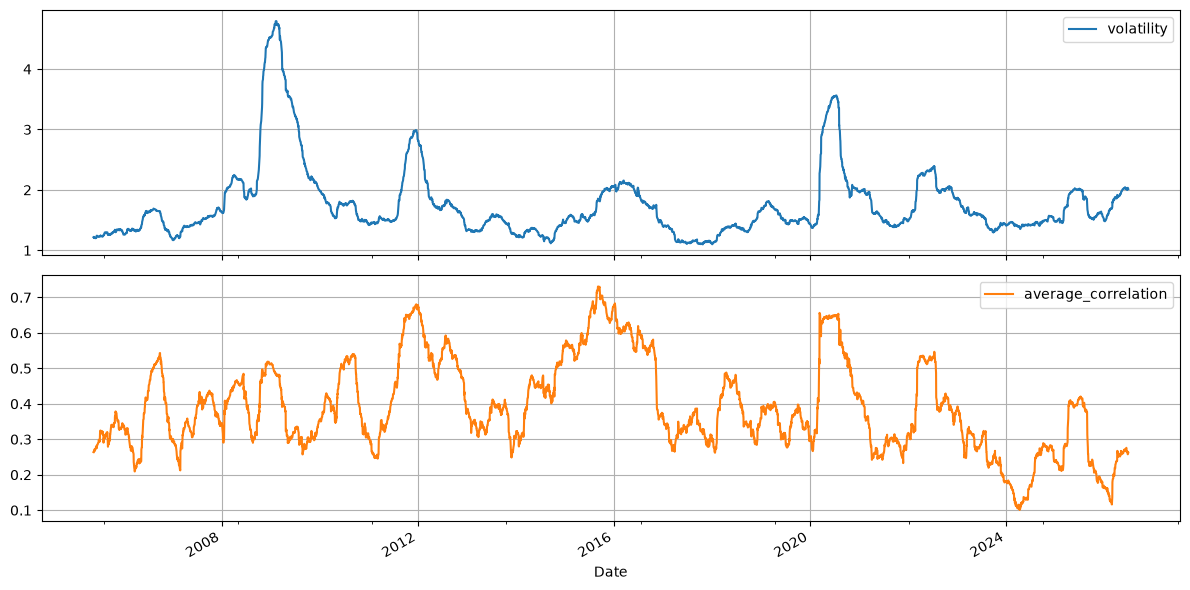

In [2]:
ba.plot_classical_measures()

# Topological Data Analysis

Each 100-day window can be viewed as a point cloud of 100 points in $\mathbb{R}^{24}$. Topological Data Analysis (TDA) is used to study the geometric structure of these point clouds.

The analysis uses **persistent homology**, which tracks topological features as the distance scale changes. In particular, two homology dimensions are considered:

- $H_1$: one-dimensional features such as loops;
- $H_2$: two-dimensional features such as cavities.

Each topological feature has a birth scale $b_i$ and a death scale $d_i$, with

$$
b_i < d_i.
$$

Its persistence, or lifetime, is

$$
p_i = d_i - b_i.
$$

In this project, each feature is therefore represented by

$$
(b_i,p_i).
$$

The birth coordinate describes the scale at which the feature appears, while the persistence measures how long it remains present. Features with larger $p_i$ persist over a wider range of scales and are therefore considered more prominent.

The collection of these points forms a **persistence diagram**, which provides a compact representation of the topological structure of each 100-day point cloud.

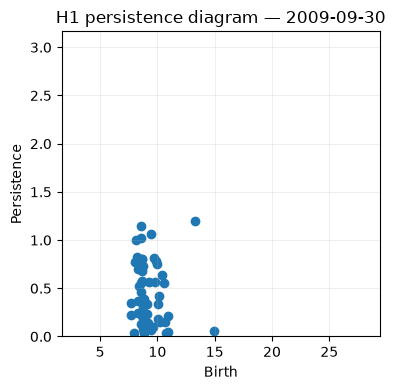

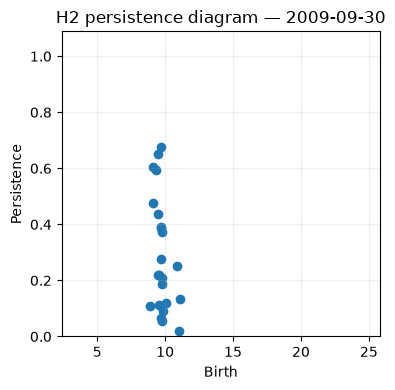

In [3]:
ba.plot_diagram("2009-09-30", "H1")
ba.plot_diagram("2009-09-30", "H2")

## Normalized Persistence Diagrams

The persistence diagrams obtained from different 100-day windows can have different geometric scales. For example, during periods of high volatility, the return point cloud may become more spread out, which can also increase the birth and persistence values in the diagram.

To reduce this scale effect, each persistence diagram is normalized by the median pairwise Euclidean distance of its corresponding point cloud.

For a point cloud

$$
X = \{\mathbf{x}_1,\ldots,\mathbf{x}_{100}\},
$$

the median distance is

$$
D_{\text{median}}
=
\operatorname{median}_{i<j}
\left\|
\mathbf{x}_i-\mathbf{x}_j
\right\|_2.
$$

A persistence point

$$
(b_i,p_i)
$$

is then transformed to

$$
\left(
\frac{b_i}{D_{\text{median}}},
\frac{p_i}{D_{\text{median}}}
\right).
$$

The normalized persistence diagram therefore keeps the relative structure of the diagram while reducing the influence of the overall scale of the return point cloud.

Both the raw and normalized persistence diagrams are kept in the analysis. This makes it possible to compare scale-dependent and more scale-independent topological representations.

# TDA-Based Stress Measures

For each 100-day point cloud, persistent homology produces a collection of topological features. Each feature has a persistence,

$$
p_1, p_2, \ldots, p_m.
$$

To summarize the overall persistence of these features, the project uses the $L^2$-norm

$$
S
=
\sqrt{
\sum_{i=1}^{m} p_i^2
}.
$$

Because the persistence values are squared, long-lived features contribute more strongly than short-lived ones. A larger value therefore indicates that the persistence diagram contains stronger or more persistent topological features.

## Raw TDA Stress

The **raw TDA stress** is calculated directly from the original persistence diagram:

$$
S_{\text{raw}}
=
\sqrt{
\sum_{i=1}^{m} p_i^2
}.
$$

It is calculated separately for $H_1$ and $H_2$.

Since the original persistence diagrams are not normalized, raw TDA stress reflects both the topological structure and the geometric scale of the point cloud.

## Normalized TDA Stress

The **normalized TDA stress** is calculated in the same way, but using the persistence values from the normalized persistence diagram.

If the normalized persistence values are

$$
\tilde p_1, \tilde p_2, \ldots, \tilde p_m,
$$

then

$$
S_{\text{normalized}}
=
\sqrt{
\sum_{i=1}^{m} \tilde p_i^2
}.
$$

Because the normalized persistence diagram has already been divided by the median pairwise distance of the corresponding point cloud, this measure reduces the influence of the overall geometric scale.

The two measures therefore have different interpretations:

- **Raw TDA stress** reflects both geometric scale and topological structure.
- **Normalized TDA stress** focuses more on the relative topological structure after reducing the scale effect.

For each 100-day window, four TDA-based stress measures are calculated:

- $H_1$ raw stress;
- $H_1$ normalized stress;
- $H_2$ raw stress;
- $H_2$ normalized stress.

## Comparison with Classical Stress Measures

The four TDA-based stress measures are compared with two classical market-stress measures:

- average stock volatility;
- average pairwise stock correlation.

All measures are calculated for the same rolling 100-day windows.

Because the measures have different numerical scales, standardized versions are used for the **visual comparison**. For each series $x_t$, the plotted value is

$$
z_t =
\frac{x_t-\bar{x}}{s_x},
$$

where $\bar{x}$ is the mean and $s_x$ is the sample standard deviation of that series over the full observation period.

The standardized curves therefore show how far each measure is above or below its own mean, measured in units of its own standard deviation. The original values in `analysis_table` are not changed; standardization is applied only when constructing the plots.

To keep the visual comparison clear, four separate plots are shown. Each plot contains one TDA stress measure together with average stock volatility and average stock correlation:

- $H_1$ raw stress;
- $H_1$ normalized stress;
- $H_2$ raw stress;
- $H_2$ normalized stress.

The comparison with volatility examines whether each TDA stress measure moves together with the magnitude of stock-return fluctuations. Comparing the raw and normalized versions also helps indicate how much of this relationship is associated with the geometric scale of the point cloud.

The comparison with average stock correlation examines whether the TDA stress measures are related to changes in the degree of co-movement between stocks.

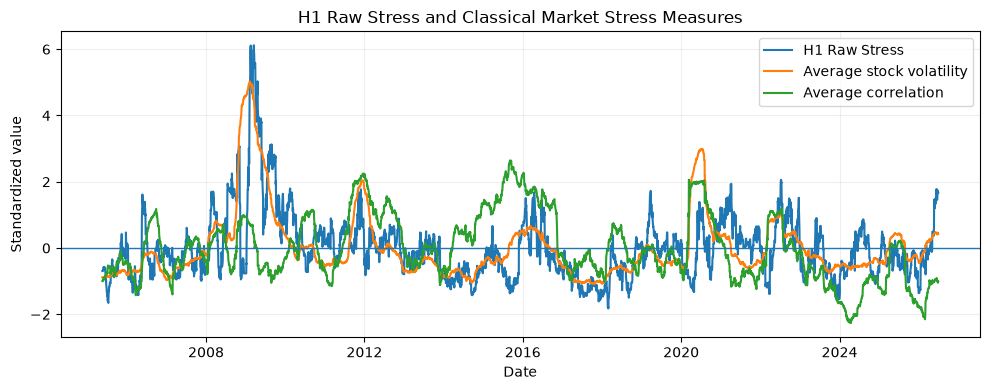

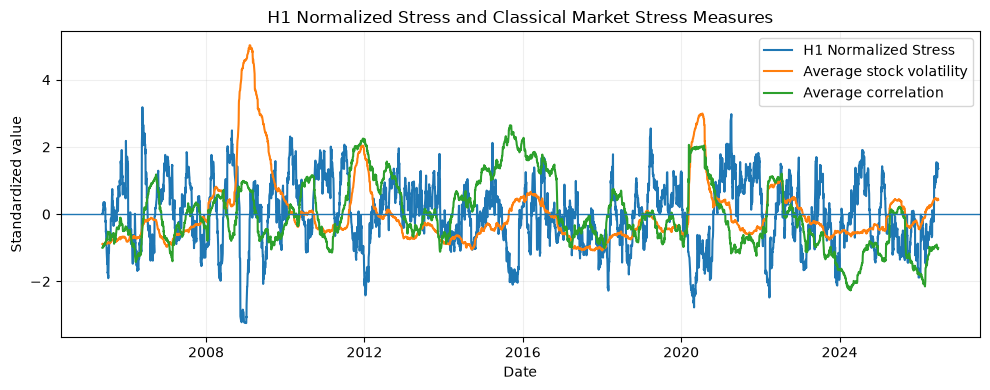

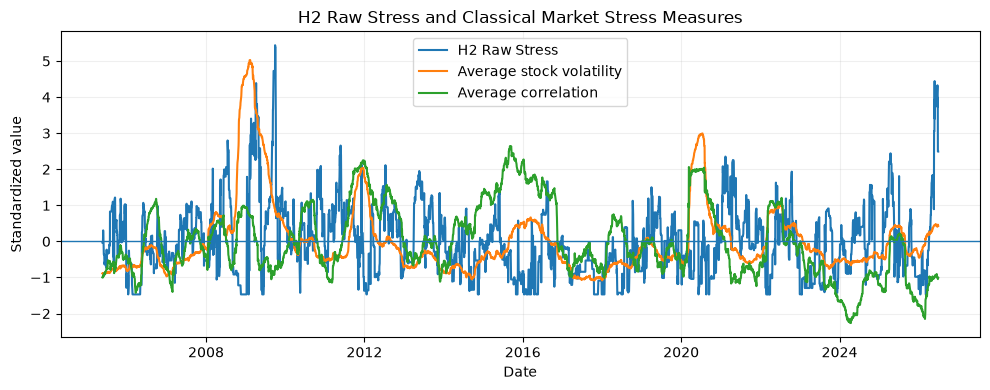

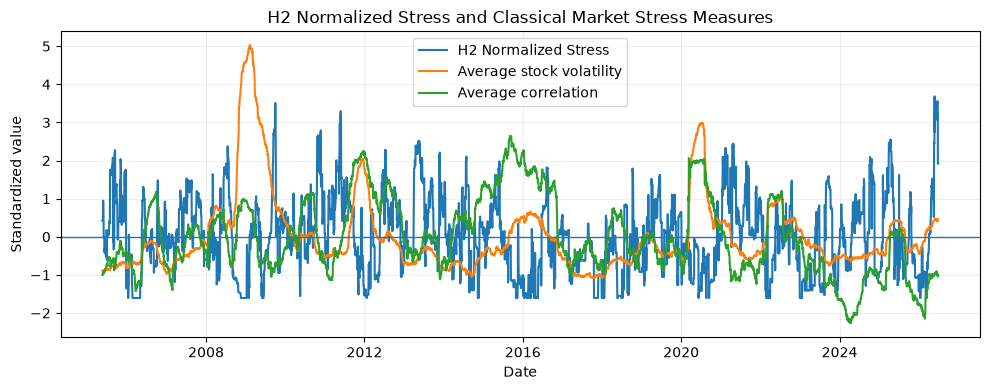

In [4]:
ba.plot_stress_comparison()

In [5]:
ba.show_correlation_table()

,TDA measure,Pearson with volatility,Spearman with volatility,Pearson with average correlation,Spearman with average correlation
0,H1 raw,0.609,0.566,0.081,0.123
1,H1 normalized,-0.252,-0.087,-0.207,-0.143
2,H2 raw,0.165,0.149,-0.085,-0.038
3,H2 normalized,-0.175,-0.107,-0.163,-0.119


## Correlation Analysis

The standardized curves in the previous plot are used only for visual comparison. The correlation coefficients are calculated from the **original, unstandardized values** in `analysis_table`.

Both **Pearson** and **Spearman correlation coefficients** are calculated. Pearson correlation measures the strength of a linear relationship, while Spearman correlation measures whether two variables tend to move in the same or opposite direction in a monotonic way. Both range from $-1$ to $1$, where values closer to $\pm 1$ indicate a stronger relationship and values closer to $0$ indicate a weaker relationship.

The strongest relationship is observed between **raw $H_1$ stress and average stock volatility**, with a Pearson correlation of approximately $0.61$ and a Spearman correlation of approximately $0.57$. This indicates a moderate positive association: periods with higher volatility also tend to have larger raw $H_1$ stress.

After normalization, this relationship becomes much weaker. The Pearson correlation falls to approximately $-0.25$ and the Spearman correlation to approximately $-0.09$. This suggests that a substantial part of the relationship between raw $H_1$ stress and volatility is associated with the geometric scale of the return point cloud.

The $H_2$ stress measures show only weak associations with volatility. The relationships between the TDA stress measures and average stock correlation are also weak, with all coefficients relatively close to zero.

Overall, the results show that **raw $H_1$ stress is moderately associated with volatility**, while normalization removes much of this association. The normalized TDA measures therefore capture aspects of the persistence diagrams that are less directly related to the two classical stress measures considered here.

# Persistence Heatmaps

A persistence diagram represents the topological features of a point cloud as points

$$
(b_i,p_i),
$$

where $b_i$ is the birth value and $p_i$ is the persistence of feature $i$.

To obtain a continuous representation of these diagrams, the project constructs **persistence heatmaps**.

## Raw and Normalized Heatmaps

Heatmaps are constructed from both:

- the **raw persistence diagrams**;
- the **normalized persistence diagrams**.

For the raw diagrams, the original birth and persistence values $(b_i,p_i)$ are used.

For the normalized diagrams, the coordinates

$$
(\tilde b_i,\tilde p_i)
$$

are used, where both coordinates have already been divided by the median pairwise distance of the corresponding point cloud.

This produces four types of heatmaps:

- $H_1$ raw heatmaps;
- $H_1$ normalized heatmaps;
- $H_2$ raw heatmaps;
- $H_2$ normalized heatmaps.

## Uniform Heatmap Area

For each of these four diagram types, a common birth-persistence area is used for all 100-day windows.

The minimum and maximum birth and persistence values across all corresponding diagrams are determined. A margin of $5\%$ of the horizontal and vertical range is then added.

This creates a uniform area that contains all observed persistence features while avoiding large regions in which no features occur.

Using the same area for every window of a given diagram type makes the resulting heatmaps directly comparable over time.

## Constructing the Heatmap

A regular grid is created over the corresponding birth-persistence area. Each persistence point contributes a Gaussian-shaped region centered at its position.

For a raw persistence point $(b_i,p_i)$, the contribution is

$$
H_i(x,y)
=
p_i
\exp
\left(
-\frac{
(x-b_i)^2+(y-p_i)^2
}{
2\sigma^2
}
\right).
$$

For a normalized persistence point $(\tilde b_i,\tilde p_i)$, the same construction is used with the normalized coordinates:

$$
H_i(x,y)
=
\tilde p_i
\exp
\left(
-\frac{
(x-\tilde b_i)^2+(y-\tilde p_i)^2
}{
2\sigma^2
}
\right).
$$

The complete heatmap is obtained by summing the contributions of all features,

$$
H(x,y)
=
\sum_i H_i(x,y).
$$

More persistent features receive a larger weight and therefore contribute more strongly to the heatmap.

The heatmap provides a **smooth representation of the persistence diagram**, while retaining information about where topological features occur in birth-persistence space. The raw heatmaps preserve geometric scale information, while the normalized heatmaps reduce this scale effect.

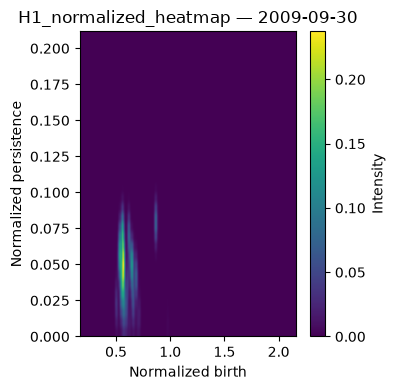

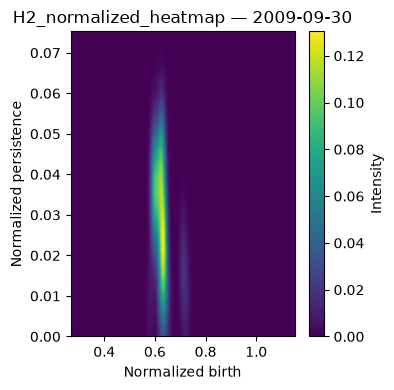

In [6]:
ba.plot_heatmap("2009-09-30", "H1_normalized_heatmap")
ba.plot_heatmap("2009-09-30", "H2_normalized_heatmap")

# Learning from Persistence Heatmaps

The persistence heatmaps provide a two-dimensional representation of each persistence diagram. Unlike the scalar TDA stress measures, they retain information about the **location and distribution** of topological features in birth-persistence space.

Both **raw** and **normalized** heatmaps are used. For each homology dimension, this gives four different input types:

- $H_1$ raw heatmaps;
- $H_1$ normalized heatmaps;
- $H_2$ raw heatmaps;
- $H_2$ normalized heatmaps.

Each heatmap is treated as a single-channel image and used as input to a **convolutional neural network (CNN)**. Each of the four heatmap types is compared with two target variables:

- average stock volatility;
- average stock correlation.

This gives a total of eight CNN experiments.

The raw heatmaps retain information about the geometric scale of the persistence diagrams, while the normalized heatmaps reduce this scale effect. Comparing the corresponding CNN results therefore allows us to examine whether this scale information is relevant for the relationship with the classical market measures.

The data are divided chronologically into training, validation, and test sets. A gap of 100 trading days is placed between these periods to reduce overlap between the rolling 100-day windows.

The objective is not to forecast future market conditions. Instead, the CNNs test whether the spatial structure of a persistence heatmap contains information related to the volatility or average correlation observed within the same 100-day window.

In [7]:
model_H1_raw_volatility = ba.build_model(ba.X_H1_raw.shape[1:])
model_H1_normalized_volatility = ba.build_model(ba.X_H1_normalized.shape[1:])
model_H2_raw_volatility = ba.build_model(ba.X_H2_raw.shape[1:])
model_H2_normalized_volatility = ba.build_model(ba.X_H2_normalized.shape[1:])

model_H1_raw_correlation = ba.build_model(ba.X_H1_raw.shape[1:])
model_H1_normalized_correlation = ba.build_model(ba.X_H1_normalized.shape[1:])
model_H2_raw_correlation = ba.build_model(ba.X_H2_raw.shape[1:])
model_H2_normalized_correlation = ba.build_model(ba.X_H2_normalized.shape[1:])

In [8]:
history_H1_raw_volatility = ba.train_model(
    model_H1_raw_volatility,
    ba.X_H1_raw_train,
    ba.y_vol_train,
    ba.X_H1_raw_val,
    ba.y_vol_val
)

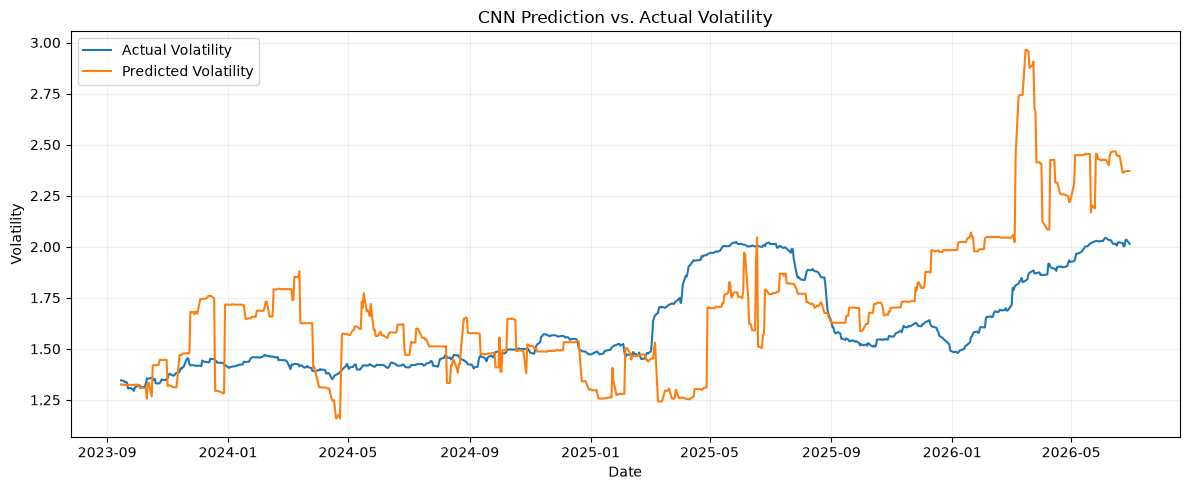

In [9]:
ba.plot_test_predictions(
    model_H1_raw_volatility,
    ba.X_H1_raw_test,
    ba.y_vol_test,
    "Volatility"
)

In [10]:
result_H1_raw_volatility = ba.evaluate_test(
    model_H1_raw_volatility,
    ba.X_H1_raw_test,
    ba.y_vol_test
)

MAE: 0.22806803759553526
MSE: 0.08777408860091264
RMSE: 0.29626692120605136
R²: -0.8000247188784619
Correlation: 0.5685883377441581


In [11]:
history_H1_normalized_volatility = ba.train_model(
    model_H1_normalized_volatility,
    ba.X_H1_normalized_train,
    ba.y_vol_train,
    ba.X_H1_normalized_val,
    ba.y_vol_val
)

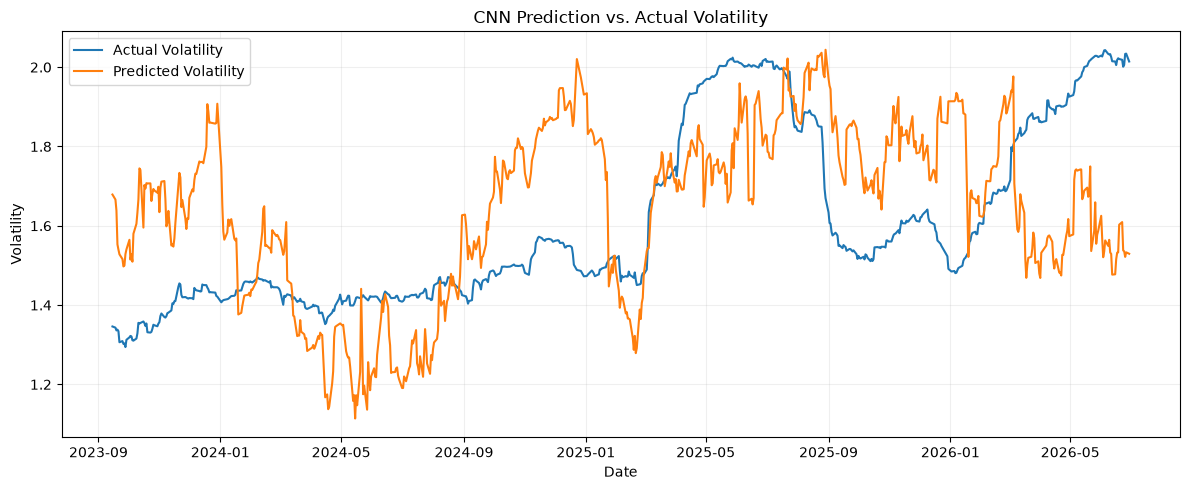

In [12]:
ba.plot_test_predictions(
    model_H1_normalized_volatility,
    ba.X_H1_normalized_test,
    ba.y_vol_test,
    "Volatility"
)

In [13]:
result_H1_normalized_volatility = ba.evaluate_test(
    model_H1_normalized_volatility,
    ba.X_H1_normalized_test,
    ba.y_vol_test
)

MAE: 0.20364239091222266
MSE: 0.05701922812704599
RMSE: 0.23878699321161945
R²: -0.16932025972623643
Correlation: 0.40536598287028586


In [14]:
history_H2_raw_volatility = ba.train_model(
    model_H2_raw_volatility,
    ba.X_H2_raw_train,
    ba.y_vol_train,
    ba.X_H2_raw_val,
    ba.y_vol_val
)

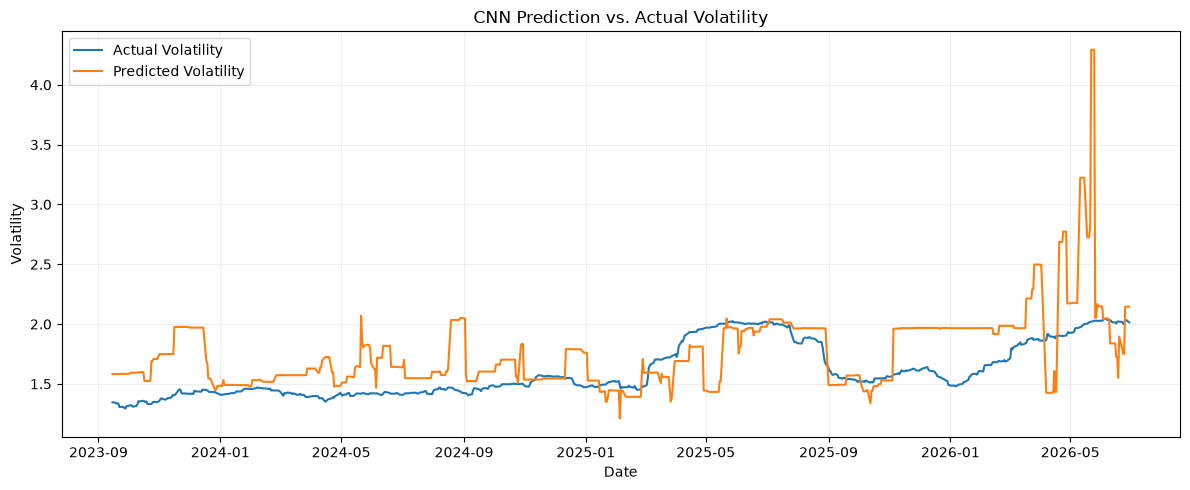

In [15]:
ba.plot_test_predictions(
    model_H2_raw_volatility,
    ba.X_H2_raw_test,
    ba.y_vol_test,
    "Volatility"
)

In [16]:
result_H2_raw_volatility = ba.evaluate_test(
    model_H2_raw_volatility,
    ba.X_H2_raw_test,
    ba.y_vol_test
)


MAE: 0.22465369734901894
MSE: 0.09995554577301488
RMSE: 0.316157469899123
R²: -1.0498356183278394
Correlation: 0.5116029143343302


In [17]:
history_H2_normalized_volatility = ba.train_model(
    model_H2_normalized_volatility,
    ba.X_H2_normalized_train,
    ba.y_vol_train,
    ba.X_H2_normalized_val,
    ba.y_vol_val
)

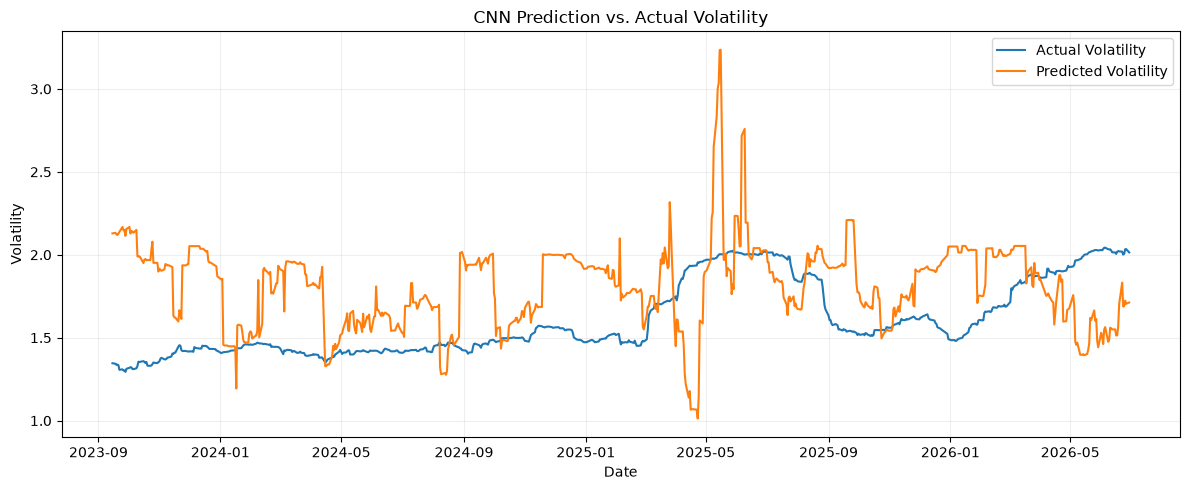

In [18]:
ba.plot_test_predictions(
    model_H2_normalized_volatility,
    ba.X_H2_normalized_test,
    ba.y_vol_test,
    "Volatility"
)

In [19]:
result_H2_normalized_volatility = ba.evaluate_test(
    model_H2_normalized_volatility,
    ba.X_H2_normalized_test,
    ba.y_vol_test
)

MAE: 0.31348264757871647
MSE: 0.14604043635752595
RMSE: 0.38215237321980083
R²: -1.9949202502640428
Correlation: 0.05830279532520879


In [20]:
history_H1_raw_correlation = ba.train_model(
    model_H1_raw_correlation,
    ba.X_H1_raw_train,
    ba.y_corr_train,
    ba.X_H1_raw_val,
    ba.y_corr_val
)

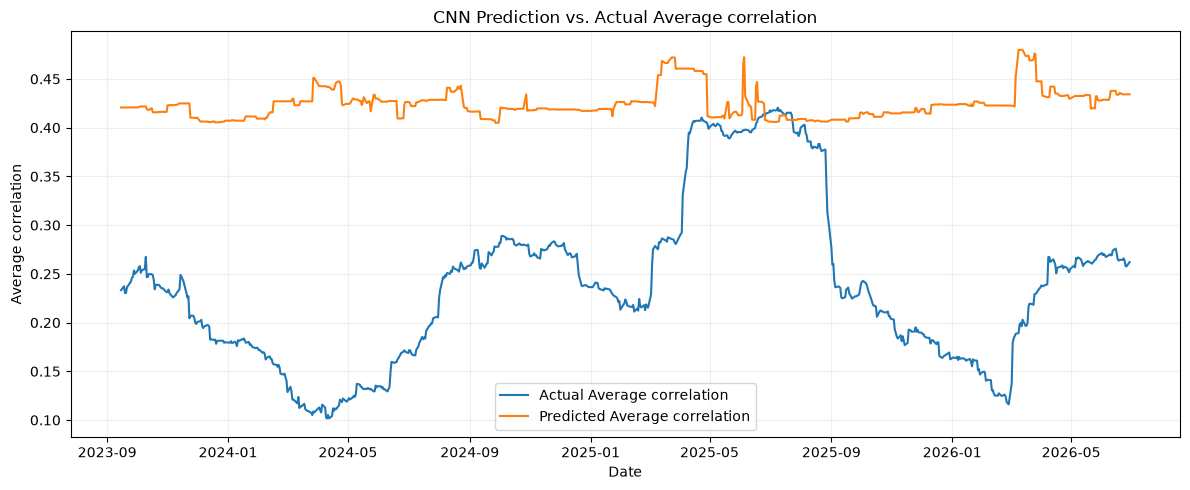

In [21]:
ba.plot_test_predictions(
    model_H1_raw_correlation,
    ba.X_H1_raw_test,
    ba.y_corr_test,
    "Average correlation"
)

In [22]:
result_H1_raw_correlation = ba.evaluate_test(
    model_H1_raw_correlation,
    ba.X_H1_raw_test,
    ba.y_corr_test
)

MAE: 0.18655656240329996
MSE: 0.04176721272004481
RMSE: 0.20437028335852747
R²: -5.1954978497173965
Correlation: -0.06357953397163152


In [ ]:
history_H1_normalized_correlation = ba.train_model(
    model_H1_normalized_correlation,
    ba.X_H1_normalized_train,
    ba.y_corr_train,
    ba.X_H1_normalized_val,
    ba.y_corr_val
)

In [ ]:
ba.plot_test_predictions(
    model_H1_normalized_correlation,
    ba.X_H1_normalized_test,
    ba.y_corr_test,
    "Average correlation"
)

In [ ]:
result_H1_normalized_correlation = ba.evaluate_test(
    model_H1_normalized_correlation,
    ba.X_H1_normalized_test,
    ba.y_corr_test
)

In [ ]:
history_H2_raw_correlation = ba.train_model(
    model_H2_raw_correlation,
    ba.X_H2_raw_train,
    ba.y_corr_train,
    ba.X_H2_raw_val,
    ba.y_corr_val
)

In [ ]:
ba.plot_test_predictions(
    model_H2_raw_correlation,
    ba.X_H2_raw_test,
    ba.y_corr_test,
    "Average correlation"
)

In [ ]:
result_H2_raw_correlation = ba.evaluate_test(
    model_H2_raw_correlation,
    ba.X_H2_raw_test,
    ba.y_corr_test
)

In [ ]:
history_H2_normalized_correlation = ba.train_model(
    model_H2_normalized_correlation,
    ba.X_H2_normalized_train,
    ba.y_corr_train,
    ba.X_H2_normalized_val,
    ba.y_corr_val
)

In [ ]:
ba.plot_test_predictions(
    model_H2_normalized_correlation,
    ba.X_H2_normalized_test,
    ba.y_corr_test,
    "Average correlation"
)

In [ ]:
result_H2_normalized_correlation = ba.evaluate_test(
    model_H2_normalized_correlation,
    ba.X_H2_normalized_test,
    ba.y_corr_test
)

In [ ]:
ba.print_evaluation_table(
    result_H1_raw_volatility,
    result_H1_normalized_volatility,
    result_H2_raw_volatility,
    result_H2_normalized_volatility,
    result_H1_raw_correlation,
    result_H1_normalized_correlation,
    result_H2_raw_correlation,
    result_H2_normalized_correlation
)

## Interpretation of the CNN Results

The CNN results show some association between the persistence heatmaps and market volatility, but the overall predictive performance remains limited.

For volatility, the strongest results are obtained from the $H_1$ heatmaps. The **normalized $H_1$ model** achieves the lowest prediction error and the best $R^2$ value,

$$
R^2 \approx -0.17,
$$

while the **raw $H_1$ model** has the highest correlation between predicted and actual volatility,

$$
\rho \approx 0.57.
$$

The raw $H_2$ model also reaches a moderate correlation of approximately $0.51$, but its more negative $R^2$ indicates that the predicted values are less accurate. The normalized $H_2$ model performs considerably worse and shows almost no correlation with volatility.

The results for average stock correlation are weaker. All four models have strongly negative $R^2$ values. The normalized $H_1$ model performs best among them, with the lowest prediction error and a correlation of approximately $0.29$, but this relationship is still weak. The other three models show correlations close to zero.

Overall, none of the eight models achieves a positive $R^2$. In terms of squared prediction error, the CNNs therefore do not outperform a simple mean-based baseline on the test set.

The clearest result is that the $H_1$ heatmaps, and to some extent the raw $H_2$ heatmaps, contain information related to changes in volatility. The relationship with average stock correlation is much weaker.

The CNN analysis should therefore be interpreted as **exploratory rather than predictive**. It demonstrates how persistence heatmaps can be used as machine-learning inputs, but the current models do not provide sufficiently accurate predictions of the classical market measures.

# Summary

This notebook presented an educational workflow for applying **Topological Data Analysis (TDA)** to financial return data. Daily returns of 24 German stocks were grouped into rolling 100-day windows and interpreted as point clouds in $\mathbb{R}^{24}$. Persistent homology was then used to identify $H_1$ and $H_2$ features and represent them through persistence diagrams.

Both raw and normalized persistence diagrams were considered. From these diagrams, TDA-based stress measures were constructed and compared with average stock volatility and average pairwise stock correlation.

The strongest statistical relationship was found between **raw $H_1$ stress and volatility**, with moderate positive Pearson and Spearman correlations. After normalization, this relationship became much weaker. This suggests that a substantial part of the raw $H_1$ stress is associated with the geometric scale of the return point cloud.

The persistence diagrams were also transformed into raw and normalized heatmaps. These retain information about the location and distribution of topological features in birth-persistence space and were used as inputs to convolutional neural networks.

The CNN results were mixed. The $H_1$ heatmaps, and to some extent the raw $H_2$ heatmaps, showed moderate relationships with volatility, while the results for average stock correlation were generally weak. Since all eight models produced negative $R^2$ values, the machine-learning analysis should be interpreted as **exploratory rather than predictive**.

Overall, the project demonstrates a complete TDA workflow,

$$
\text{returns}
\rightarrow
\text{rolling point clouds}
\rightarrow
\text{persistent homology}
\rightarrow
\text{persistence diagrams}
\rightarrow
\text{stress measures and heatmaps}
\rightarrow
\text{statistical and machine-learning analysis}.
$$

The main purpose of the notebook is not to establish a new financial indicator, but to demonstrate how persistence diagrams and related TDA methods can be constructed, normalized, visualized, and incorporated into a broader data-analysis workflow.